In [1]:
import pandas as pd
import re
from functools import reduce
from scipy.stats import pearsonr
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error 
from scipy.stats import zscore
import matplotlib.pyplot as plt 
from tensorflow.keras.models import load_model
import seaborn as sns
import math

In [6]:
pseudo_bulk_gene_expression_df=pd.read_csv("/data/kumarr17/single_cell_cross_tissue_ML_analysis/pseudo_bulk_gene_expression.csv",index_col='sampleID')
tcga_bulk_gene_expression_df=pd.read_csv("/data/kumarr17/merged_sample_mtx/TCGA_Merged_mRNA_Expression.tsv", index_col='Unnamed: 0')

In [8]:
tcga_features = pd.read_csv("/data/kumarr17/common_features_ver3.txt", header=None)
cyt_features = pd.read_csv("/data/kumarr17/common_cyt_nichenet_gulden_tcga.txt", header=None)
tcga_features_list=list(tcga_features[0])
cyt_features_list=list(cyt_features[0])
filtered_model_feature_list=tcga_features_list
cyt_of_interest=cyt_features_list
cyt_of_interest = [x for x in cyt_of_interest if x not in ['CCL3L3', 'CCL3L1']]

In [9]:
df_tcga_features=tcga_bulk_gene_expression_df[filtered_model_feature_list]
df_tcga_cyt_col=tcga_bulk_gene_expression_df[cyt_of_interest]

In [10]:
pseudo_bulk_gene_expression_df_features=pseudo_bulk_gene_expression_df[filtered_model_feature_list]
pseudo_bulk_gene_expression_df_cyt_col=pseudo_bulk_gene_expression_df[cyt_of_interest]

### Training on TCGA bulk and testing on single cell pseudobulk

In [11]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Clear previous TensorFlow state
# -----------------------------
tf.keras.backend.clear_session()

cyt_tmp = cyt_of_interest

# ============================================================
# 1. Prepare TCGA training features
# ============================================================

X_train_raw = df_tcga_features.values.astype("float32")

# Same row-wise z-score transformation used previously
X_train_raw = (
    X_train_raw - X_train_raw.mean(axis=1, keepdims=True)
) / (
    X_train_raw.std(axis=1, keepdims=True) + 1e-8
)


# ============================================================
# 2. Prepare pseudobulk features
# ============================================================

# IMPORTANT:
# columns must be in exactly the same order as TCGA training data
pseudo_bulk_gene_expression_df_features = (
    pseudo_bulk_gene_expression_df_features[
        df_tcga_features.columns
    ]
)

X_test_raw = (
    pseudo_bulk_gene_expression_df_features
    .values
    .astype("float32")
)

# Apply the SAME row-wise z-score procedure
X_test_raw = (
    X_test_raw - X_test_raw.mean(axis=1, keepdims=True)
) / (
    X_test_raw.std(axis=1, keepdims=True) + 1e-8
)


# ============================================================
# 3. Feature scaling
#    Fit ONLY on TCGA
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_raw
).astype("float32")

X_test = scaler.transform(
    X_test_raw
).astype("float32")


# ============================================================
# 4. FCNN architecture
# ============================================================

def build_fcnn(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


# ============================================================
# 5. Early stopping
# ============================================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# ============================================================
# 6. Train full TCGA model and predict pseudobulk
# ============================================================

prediction_dict = {}

for cytokine_to_check in cyt_tmp:

    print("\n==============================")
    print("Cytokine:", cytokine_to_check)
    print("==============================")

    # Target from TCGA
    y_train = (
        df_tcga_cyt_col[[cytokine_to_check]]
        .values
        .astype("float32")
    )

    # Clear previous model
    tf.keras.backend.clear_session()

    model = build_fcnn(
        X_train.shape[1]
    )

    # Train using ALL TCGA samples
    #
    # validation_split is used only for early stopping;
    # prediction dataset is NEVER used during training.
    model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predict pseudobulk samples
    y_pred = model.predict(
        X_test,
        verbose=0
    ).ravel()

    prediction_dict[cytokine_to_check] = y_pred

    print(
        "Predicted",
        len(y_pred),
        "pseudobulk samples"
    )


# ============================================================
# 7. Prediction dataframe
# ============================================================

pseudo_bulk_cytokine_predictions = pd.DataFrame(
    prediction_dict,
    index=pseudo_bulk_gene_expression_df_features.index
)

pseudo_bulk_cytokine_predictions


Cytokine: INHA


2026-09-17 09:41:14.880058: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-09-17 09:41:14.880096: W tensorflow/stream_executor/cuda/cuda_driver.cc:269] failed call to cuInit: UNKNOWN ERROR (303)
2026-09-17 09:41:14.880116: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cn0055): /proc/driver/nvidia/version does not exist
2026-09-17 09:41:14.882786: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  SSE4.1 SSE4.2 AVX AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


Predicted 1062 pseudobulk samples

Cytokine: FGF7
Predicted 1062 pseudobulk samples

Cytokine: BMP6
Predicted 1062 pseudobulk samples

Cytokine: IL25
Predicted 1062 pseudobulk samples

Cytokine: CCL21
Predicted 1062 pseudobulk samples

Cytokine: LIPH
Predicted 1062 pseudobulk samples

Cytokine: SFTPA1
Predicted 1062 pseudobulk samples

Cytokine: FGF23
Predicted 1062 pseudobulk samples

Cytokine: ADCYAP1
Predicted 1062 pseudobulk samples

Cytokine: MIA
Predicted 1062 pseudobulk samples

Cytokine: VCAM1
Predicted 1062 pseudobulk samples

Cytokine: BMP15
Predicted 1062 pseudobulk samples

Cytokine: ARF1
Predicted 1062 pseudobulk samples

Cytokine: ANGPTL4
Predicted 1062 pseudobulk samples

Cytokine: PODXL2
Predicted 1062 pseudobulk samples

Cytokine: IL18
Predicted 1062 pseudobulk samples

Cytokine: FGF21
Predicted 1062 pseudobulk samples

Cytokine: COL4A5
Predicted 1062 pseudobulk samples

Cytokine: FAT4
Predicted 1062 pseudobulk samples

Cytokine: MADCAM1
Predicted 1062 pseudobulk sampl

,INHA,FGF7,BMP6,IL25,CCL21,LIPH,SFTPA1,FGF23,ADCYAP1,MIA,...,ZP3,PSEN1,B2M,LTF,GALP,ANGPT2,CALCB,CSH1,CNTN2,NODAL
sampleID,,,,,,,,,,,,,,,,,,,,,
HGSOC01,61.914822,146.001816,155.221664,-0.014117,32816.582031,22.130026,10987.249023,2.960658,5.589542,-18.769171,...,154.652695,1345.810669,179799.078125,12356.005859,-0.679229,108.177994,14.665527,4.671948,-112.955879,0.182031
HGSOC02,173.696243,93.338860,250.254105,-0.515190,12767.290039,23.496403,3608.795410,2.859948,-4.671906,-27.040907,...,426.489166,3162.460205,76412.914062,31.315660,-1.080320,159.773407,57.957401,5.898362,-128.964844,0.910329
HGSOC03,139.140228,134.923676,230.126328,0.195384,18485.382812,44.126228,9062.057617,3.083062,6.795589,-20.976225,...,126.536690,1849.343872,323974.000000,5925.080566,-1.221973,168.714615,17.685966,6.819693,-134.531998,4.223363
HGSOC04,152.892670,80.775513,213.729965,-0.136330,13523.287109,60.825386,4974.181641,3.747070,2.334510,-27.141296,...,619.773865,2185.135010,128165.835938,4419.319824,-1.231021,151.469666,35.284721,6.272561,-132.720978,1.866453
HGSOC05,155.014481,144.578918,287.223785,0.162574,37226.644531,54.187183,8468.846680,3.283029,1.668663,-7.374527,...,126.995323,2034.705444,308229.500000,5534.466309,-1.101684,161.050201,26.392401,6.453711,-129.554108,2.351339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSE181919_LP15,197.550781,131.235809,374.176147,-0.294485,13592.258789,149.965088,4645.890137,4.304803,-10.814930,-4.817850,...,315.326324,2427.560791,202165.375000,3256.233398,-1.770970,193.384659,51.868530,7.053002,-157.674240,-0.165354
GSE181919_LP16,203.520599,133.005753,319.396332,0.090370,29249.677734,345.008240,5356.321777,4.460073,-2.490681,-27.086603,...,301.067841,2838.912842,212134.484375,1882.112183,-1.671553,183.469131,37.908642,7.232262,-154.409088,0.306432
GSE181919_LP17,166.308701,140.111328,331.694183,-0.058412,21303.806641,279.610626,5489.770020,3.678800,-9.052952,-30.808384,...,348.373383,2555.775146,166629.125000,488.850983,-1.504785,176.346497,51.039234,6.505196,-147.003876,-2.973559


In [12]:
pseudo_bulk_cytokine_predictions

,INHA,FGF7,BMP6,IL25,CCL21,LIPH,SFTPA1,FGF23,ADCYAP1,MIA,...,ZP3,PSEN1,B2M,LTF,GALP,ANGPT2,CALCB,CSH1,CNTN2,NODAL
sampleID,,,,,,,,,,,,,,,,,,,,,
HGSOC01,61.914822,146.001816,155.221664,-0.014117,32816.582031,22.130026,10987.249023,2.960658,5.589542,-18.769171,...,154.652695,1345.810669,179799.078125,12356.005859,-0.679229,108.177994,14.665527,4.671948,-112.955879,0.182031
HGSOC02,173.696243,93.338860,250.254105,-0.515190,12767.290039,23.496403,3608.795410,2.859948,-4.671906,-27.040907,...,426.489166,3162.460205,76412.914062,31.315660,-1.080320,159.773407,57.957401,5.898362,-128.964844,0.910329
HGSOC03,139.140228,134.923676,230.126328,0.195384,18485.382812,44.126228,9062.057617,3.083062,6.795589,-20.976225,...,126.536690,1849.343872,323974.000000,5925.080566,-1.221973,168.714615,17.685966,6.819693,-134.531998,4.223363
HGSOC04,152.892670,80.775513,213.729965,-0.136330,13523.287109,60.825386,4974.181641,3.747070,2.334510,-27.141296,...,619.773865,2185.135010,128165.835938,4419.319824,-1.231021,151.469666,35.284721,6.272561,-132.720978,1.866453
HGSOC05,155.014481,144.578918,287.223785,0.162574,37226.644531,54.187183,8468.846680,3.283029,1.668663,-7.374527,...,126.995323,2034.705444,308229.500000,5534.466309,-1.101684,161.050201,26.392401,6.453711,-129.554108,2.351339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSE181919_LP15,197.550781,131.235809,374.176147,-0.294485,13592.258789,149.965088,4645.890137,4.304803,-10.814930,-4.817850,...,315.326324,2427.560791,202165.375000,3256.233398,-1.770970,193.384659,51.868530,7.053002,-157.674240,-0.165354
GSE181919_LP16,203.520599,133.005753,319.396332,0.090370,29249.677734,345.008240,5356.321777,4.460073,-2.490681,-27.086603,...,301.067841,2838.912842,212134.484375,1882.112183,-1.671553,183.469131,37.908642,7.232262,-154.409088,0.306432
GSE181919_LP17,166.308701,140.111328,331.694183,-0.058412,21303.806641,279.610626,5489.770020,3.678800,-9.052952,-30.808384,...,348.373383,2555.775146,166629.125000,488.850983,-1.504785,176.346497,51.039234,6.505196,-147.003876,-2.973559


In [13]:
pseudo_bulk_gene_expression_df_cyt_col
corr = pseudo_bulk_cytokine_predictions.corrwith(pseudo_bulk_gene_expression_df_cyt_col, axis=0)

#### Training on Pseudobulk single cell and testing on TCGA bulk

In [14]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Clear previous TensorFlow state
# -----------------------------
tf.keras.backend.clear_session()

cyt_tmp = cyt_of_interest

# ============================================================
# 1. Prepare pseudobulk TRAINING features
# ============================================================

# Make sure training features are in the desired gene order
pseudo_bulk_gene_expression_df_features = (
    pseudo_bulk_gene_expression_df_features[
        df_tcga_features.columns
    ]
)

X_train_raw = (
    pseudo_bulk_gene_expression_df_features
    .values
    .astype("float32")
)

# Same row-wise z-score transformation
X_train_raw = (
    X_train_raw - X_train_raw.mean(axis=1, keepdims=True)
) / (
    X_train_raw.std(axis=1, keepdims=True) + 1e-8
)


# ============================================================
# 2. Prepare TCGA TEST features
# ============================================================

# Same feature order as pseudobulk training data
df_tcga_features = df_tcga_features[
    pseudo_bulk_gene_expression_df_features.columns
]

X_test_raw = (
    df_tcga_features
    .values
    .astype("float32")
)

# Same row-wise z-score transformation
X_test_raw = (
    X_test_raw - X_test_raw.mean(axis=1, keepdims=True)
) / (
    X_test_raw.std(axis=1, keepdims=True) + 1e-8
)


# ============================================================
# 3. Feature scaling
#    Fit ONLY on pseudobulk training data
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train_raw
).astype("float32")

X_test = scaler.transform(
    X_test_raw
).astype("float32")


# ============================================================
# 4. FCNN architecture
# ============================================================

def build_fcnn(input_dim):

    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(32, activation="relu"),
        layers.Dense(1)
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="mean_squared_error",
        metrics=["mae"]
    )

    return model


# ============================================================
# 5. Early stopping
# ============================================================

early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


# ============================================================
# 6. Train on pseudobulk and predict TCGA
# ============================================================

prediction_dict = {}

for cytokine_to_check in cyt_tmp:

    print("\n==============================")
    print("Cytokine:", cytokine_to_check)
    print("==============================")

    # Target from pseudobulk
    y_train = (
        pseudo_bulk_gene_expression_df_cyt_col[
            [cytokine_to_check]
        ]
        .values
        .astype("float32")
    )

    tf.keras.backend.clear_session()

    model = build_fcnn(
        X_train.shape[1]
    )

    model.fit(
        X_train,
        y_train,
        validation_split=0.1,
        epochs=50,
        batch_size=128,
        verbose=0,
        callbacks=[early_stop]
    )

    # Predict TCGA samples
    y_pred = model.predict(
        X_test,
        verbose=0
    ).ravel()

    prediction_dict[cytokine_to_check] = y_pred

    print(
        "Predicted",
        len(y_pred),
        "TCGA samples"
    )


# ============================================================
# 7. TCGA prediction dataframe
# ============================================================

tcga_cytokine_predictions = pd.DataFrame(
    prediction_dict,
    index=df_tcga_features.index
)

tcga_cytokine_predictions


Cytokine: INHA
Predicted 9491 TCGA samples

Cytokine: FGF7
Predicted 9491 TCGA samples

Cytokine: BMP6
Predicted 9491 TCGA samples

Cytokine: IL25
Predicted 9491 TCGA samples

Cytokine: CCL21
Predicted 9491 TCGA samples

Cytokine: LIPH
Predicted 9491 TCGA samples

Cytokine: SFTPA1
Predicted 9491 TCGA samples

Cytokine: FGF23
Predicted 9491 TCGA samples

Cytokine: ADCYAP1
Predicted 9491 TCGA samples

Cytokine: MIA
Predicted 9491 TCGA samples

Cytokine: VCAM1
Predicted 9491 TCGA samples

Cytokine: BMP15
Predicted 9491 TCGA samples

Cytokine: ARF1
Predicted 9491 TCGA samples

Cytokine: ANGPTL4
Predicted 9491 TCGA samples

Cytokine: PODXL2
Predicted 9491 TCGA samples

Cytokine: IL18
Predicted 9491 TCGA samples

Cytokine: FGF21
Predicted 9491 TCGA samples

Cytokine: COL4A5
Predicted 9491 TCGA samples

Cytokine: FAT4
Predicted 9491 TCGA samples

Cytokine: MADCAM1
Predicted 9491 TCGA samples

Cytokine: RGMA
Predicted 9491 TCGA samples

Cytokine: PDGFC
Predicted 9491 TCGA samples

Cytokine: P

,INHA,FGF7,BMP6,IL25,CCL21,LIPH,SFTPA1,FGF23,ADCYAP1,MIA,...,ZP3,PSEN1,B2M,LTF,GALP,ANGPT2,CALCB,CSH1,CNTN2,NODAL
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-2803-03,-1.880440,4.272484,-0.106518,-0.355878,0.823915,-0.918214,2.075685,-0.550045,1.693794,-0.379971,...,2.695105,-0.621265,62.787121,2.042795,0.960879,1.839647,0.302101,-0.801559,-2.070481,0.335443
TCGA-AB-2805-03,4.442814,5.964088,-0.434863,1.606211,-1.400748,-1.500960,0.849253,1.641809,-0.576851,-1.659481,...,3.262799,0.465930,104.518181,1.982158,0.503949,0.914701,0.868466,-1.932547,-2.751900,0.492744
TCGA-AB-2806-03,0.898821,8.777391,0.430935,0.088789,-3.669526,2.533623,2.163075,1.168204,0.052216,-0.455294,...,4.401997,1.832108,66.943565,2.865511,1.365664,1.558829,1.909474,-2.426974,0.765303,-0.759287
TCGA-AB-2807-03,2.218269,6.431005,2.378878,1.824879,0.563062,0.419916,2.235932,1.914135,3.396482,-1.658955,...,3.535702,2.155243,69.858032,3.139534,0.097274,-2.191665,0.900340,-3.096794,-1.337502,-0.347820
TCGA-AB-2808-03,1.643757,9.285559,1.979194,0.918632,-1.882379,-0.281068,1.453965,0.712482,2.500428,-1.661078,...,1.904201,0.604017,78.030144,1.926532,0.362855,0.344689,2.712730,-0.194738,-1.091619,-0.280412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I-01,-0.185303,0.785119,0.121812,-0.020407,0.622815,6.300688,1.713783,-1.175810,0.937291,4.266962,...,2.031095,3.095382,118.750862,2.810982,-0.073992,-2.916730,4.037562,-1.543712,2.422144,0.927836
TCGA-VQ-AA6J-01,-0.356151,0.049605,0.726018,-0.506734,1.298571,4.302543,2.956180,-1.736714,-0.274582,1.817578,...,1.923473,-0.131633,118.503227,1.770133,0.299092,-0.761182,0.848074,-0.543496,0.404687,1.032911
TCGA-VQ-AA6K-01,-0.324841,1.638479,-1.376831,1.046578,0.767618,3.817143,4.308085,-1.251901,0.193995,1.734779,...,3.125489,0.101074,166.303818,2.158763,3.144288,-2.136267,1.187350,-1.047187,-0.100098,1.119402


In [15]:
tcga_cytokine_predictions

,INHA,FGF7,BMP6,IL25,CCL21,LIPH,SFTPA1,FGF23,ADCYAP1,MIA,...,ZP3,PSEN1,B2M,LTF,GALP,ANGPT2,CALCB,CSH1,CNTN2,NODAL
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-2803-03,-1.880440,4.272484,-0.106518,-0.355878,0.823915,-0.918214,2.075685,-0.550045,1.693794,-0.379971,...,2.695105,-0.621265,62.787121,2.042795,0.960879,1.839647,0.302101,-0.801559,-2.070481,0.335443
TCGA-AB-2805-03,4.442814,5.964088,-0.434863,1.606211,-1.400748,-1.500960,0.849253,1.641809,-0.576851,-1.659481,...,3.262799,0.465930,104.518181,1.982158,0.503949,0.914701,0.868466,-1.932547,-2.751900,0.492744
TCGA-AB-2806-03,0.898821,8.777391,0.430935,0.088789,-3.669526,2.533623,2.163075,1.168204,0.052216,-0.455294,...,4.401997,1.832108,66.943565,2.865511,1.365664,1.558829,1.909474,-2.426974,0.765303,-0.759287
TCGA-AB-2807-03,2.218269,6.431005,2.378878,1.824879,0.563062,0.419916,2.235932,1.914135,3.396482,-1.658955,...,3.535702,2.155243,69.858032,3.139534,0.097274,-2.191665,0.900340,-3.096794,-1.337502,-0.347820
TCGA-AB-2808-03,1.643757,9.285559,1.979194,0.918632,-1.882379,-0.281068,1.453965,0.712482,2.500428,-1.661078,...,1.904201,0.604017,78.030144,1.926532,0.362855,0.344689,2.712730,-0.194738,-1.091619,-0.280412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I-01,-0.185303,0.785119,0.121812,-0.020407,0.622815,6.300688,1.713783,-1.175810,0.937291,4.266962,...,2.031095,3.095382,118.750862,2.810982,-0.073992,-2.916730,4.037562,-1.543712,2.422144,0.927836
TCGA-VQ-AA6J-01,-0.356151,0.049605,0.726018,-0.506734,1.298571,4.302543,2.956180,-1.736714,-0.274582,1.817578,...,1.923473,-0.131633,118.503227,1.770133,0.299092,-0.761182,0.848074,-0.543496,0.404687,1.032911
TCGA-VQ-AA6K-01,-0.324841,1.638479,-1.376831,1.046578,0.767618,3.817143,4.308085,-1.251901,0.193995,1.734779,...,3.125489,0.101074,166.303818,2.158763,3.144288,-2.136267,1.187350,-1.047187,-0.100098,1.119402


In [16]:
df_tcga_cyt_col_v1=df_tcga_cyt_col[tcga_cytokine_predictions.columns]

In [17]:
df_tcga_cyt_col_v1

,INHA,FGF7,BMP6,IL25,CCL21,LIPH,SFTPA1,FGF23,ADCYAP1,MIA,...,ZP3,PSEN1,B2M,LTF,GALP,ANGPT2,CALCB,CSH1,CNTN2,NODAL
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
TCGA-AB-2803-03,5.1440,15.4321,18.9815,0.0,0.0000,14.4033,2.0576,1.0288,0.0000,3.3230,...,136.6564,2614.1975,73139.9074,858.0247,0.0000,111.1111,0.0000,0.0,5.1440,10.2881
TCGA-AB-2805-03,0.0000,0.6693,11.5797,0.0,0.0000,7.3628,0.0000,0.0000,0.0000,4.9933,...,65.1339,4286.4793,33497.9920,107.0950,0.6693,109.7724,0.0000,0.0,8.7015,21.4190
TCGA-AB-2806-03,0.0000,17.1865,29.5544,0.0,0.6365,15.9134,2.5461,0.6365,0.0000,7.1356,...,145.5697,2728.8351,23352.6416,26.7346,0.0000,96.7537,1.9096,0.0,5.7288,10.1846
TCGA-AB-2807-03,3.9722,97.3188,83.1480,0.0,0.0000,2.9791,14.8957,0.9930,16.8818,1.0427,...,120.0497,2016.8818,41025.8193,39.7219,0.0000,178.7488,0.9930,0.0,7.9444,30.7845
TCGA-AB-2808-03,0.0000,14.1398,20.7306,0.0,0.0000,7.0699,0.0000,0.0000,0.7855,2.4666,...,49.8272,2492.5373,38730.5577,14278.0833,1.5711,225.4517,0.0000,0.0,3.1422,11.7832
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-VQ-AA6I-01,0.9621,112.0799,91.1575,0.0,656.3646,4186.6394,0.4810,0.0000,8.1775,30.3049,...,67.8468,2739.4624,59258.0121,9938.3080,0.0000,238.8311,0.0000,0.0,1.2026,3.6077
TCGA-VQ-AA6J-01,11.9710,121.1468,58.0308,0.0,455.1386,1424.3132,0.0000,0.0000,0.0000,59.1608,...,84.6376,1947.6866,66351.5892,1588.3163,0.0000,523.8523,0.2394,0.0,3.8307,6.2249
TCGA-VQ-AA6K-01,127.5618,393.6396,122.3887,0.0,518.3746,1754.7703,0.0000,1.0601,71.7314,25.0106,...,36.3145,2693.2862,52730.3887,12.0141,0.0000,291.8728,0.0000,0.0,2.4735,9.1873


In [18]:
corr_v1 = tcga_cytokine_predictions.corrwith(df_tcga_cyt_col_v1, axis=0)

In [19]:
df=pd.DataFrame({'trained_on_TCGA_bulk_tested_on_sc':corr,'sc_pseudobulk_tested_on_TCGA_bulk':corr_v1})

In [20]:
df

,trained_on_TCGA_bulk_tested_on_sc,sc_pseudobulk_tested_on_TCGA_bulk
INHA,0.225922,0.031438
FGF7,0.453122,0.110116
BMP6,0.197170,-0.099185
IL25,-0.020498,-0.009722
CCL21,0.062924,-0.009794
...,...,...
ANGPT2,0.515590,0.181605
CALCB,0.084219,0.005357
CSH1,0.000643,-0.009528
CNTN2,0.162987,0.226373


In [21]:
### Plotting figure 2B

/tmp/ipykernel_112151/1263929559.py:113: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(


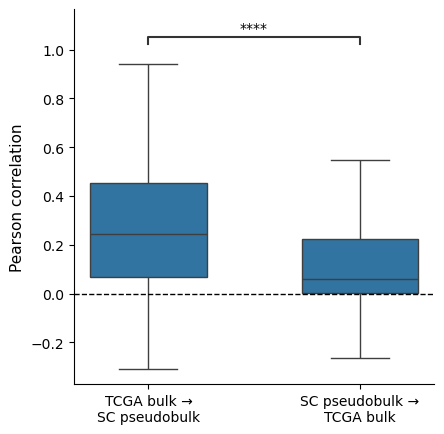

In [22]:
from statannotations.Annotator import Annotator
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# ============================================================
# 1. Convert wide dataframe to long format
# ============================================================

df_long = df[
    [
        "trained_on_TCGA_bulk_tested_on_sc",
        "sc_pseudobulk_tested_on_TCGA_bulk"
    ]
].melt(
    var_name="metric",
    value_name="value"
)

# ============================================================
# 2. Define order
# ============================================================

order = [
    "trained_on_TCGA_bulk_tested_on_sc",
    "sc_pseudobulk_tested_on_TCGA_bulk"
]

pairs = [
    (
        "trained_on_TCGA_bulk_tested_on_sc",
        "sc_pseudobulk_tested_on_TCGA_bulk"
    )
]


# ============================================================
# 3. Plot
# ============================================================

fig, ax = plt.subplots(figsize=(4.5, 5))

sns.boxplot(
    data=df_long,
    x="metric",
    y="value",
    order=order,
    showfliers=False,
    width=0.55,
    ax=ax
)

# Optional: show individual cytokines
#sns.stripplot(
#    data=df_long,
#    x="metric",
#    y="value",
#    order=order,
#    size=3,
#    alpha=0.35,
#    jitter=0.15,
#    ax=ax
#)


# ============================================================
# 4. Zero reference line
# ============================================================

ax.axhline(
    0,
    linestyle="--",
    color="black",
    linewidth=1
)


# ============================================================
# 5. Statistical comparison
# ============================================================

annotator = Annotator(
    ax,
    pairs,
    data=df_long,
    x="metric",
    y="value",
    order=order
)

annotator.configure(
    test="Mann-Whitney",
    text_format="star",
    loc="inside",
    verbose=0
)

annotator.apply_and_annotate()


# ============================================================
# 6. Clean labels
# ============================================================

pretty_labels = {
    "trained_on_TCGA_bulk_tested_on_sc":
        "TCGA bulk →\nSC pseudobulk",

    "sc_pseudobulk_tested_on_TCGA_bulk":
        "SC pseudobulk →\nTCGA bulk"
}

ax.set_xticklabels(
    [pretty_labels[x] for x in order],
    fontsize=10
)

ax.set_ylabel(
    "Pearson correlation",
    fontsize=11
)

ax.set_xlabel("")

ax.tick_params(
    axis="y",
    labelsize=10
)

sns.despine(ax=ax)
ax.grid(False)

fig.subplots_adjust(
    left=0.18,
    right=0.98,
    bottom=0.22,
    top=0.97
)

plt.show()

In [31]:
# Save as high-quality vector SVG for the manuscript
#fig.savefig(
#    "/data/kumarr17/cytokine_figure_directory/cross_modality_TCGA_SC_comparison.svg",
#    format="svg",
#    bbox_inches="tight",
#    transparent=False
#)

#plt.show()